# Attock Petroleum Limited (APL) Stock Price Analysis and Forecasting

This project analyzes the historical stock prices of Attock Petroleum Limited (APL)
and uses time-series analysis to forecast its future closing prices.

The analysis includes data collection, exploratory data analysis, stationarity testing,
differencing, ACF/PACF analysis, ARIMA modeling, and short-term forecasting.

## 1. Importing the Required Libraries

The following libraries are used to collect, analyze, visualize, and model the stock price data.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

## 2. Collecting Historical Stock Data

Historical data for Attock Petroleum Limited (APL) is downloaded from Yahoo Finance.
The analysis covers the period from December 10, 2014 to December 10, 2024.

In [20]:
ticker = "APL.KA"

data = yf.download(
    ticker,
    start="2014-12-10",
    end="2024-12-11",
    auto_adjust=False
)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,APL.KA,APL.KA,APL.KA,APL.KA,APL.KA,APL.KA
Date,,,,,,
2014-12-10,146.031631,348.739990,353.000000,348.333344,352.733337,21075
2014-12-11,145.303040,347.000000,349.333344,345.000000,348.339996,52575
2014-12-12,146.746277,350.446655,351.333344,345.666656,345.673340,36825
2014-12-15,146.274567,349.320007,353.000000,346.813324,350.000000,20250
2014-12-16,143.781631,343.366669,356.666656,340.033325,352.600006,40500


## 3. Initial Data Inspection

Before starting the analysis, the dataset is checked for its dimensions,
available columns, and missing values.

In [21]:
print("Dataset shape:", data.shape)

print("\nColumns:")
print(data.columns)

print("\nMissing values:")
print(data.isnull().sum())

Dataset shape: (2598, 6)

Columns:
MultiIndex([('Adj Close', 'APL.KA'),
            (    'Close', 'APL.KA'),
            (     'High', 'APL.KA'),
            (      'Low', 'APL.KA'),
            (     'Open', 'APL.KA'),
            (   'Volume', 'APL.KA')],
           names=['Price', 'Ticker'])

Missing values:
Price      Ticker
Adj Close  APL.KA    0
Close      APL.KA    0
High       APL.KA    0
Low        APL.KA    0
Open       APL.KA    0
Volume     APL.KA    0
dtype: int64


## 4. Preparing the Closing Price Data

The closing price is selected because it is the main variable used for
the time-series analysis and forecasting.

The date index is also converted to datetime format to preserve the
time-series structure of the data.

In [22]:
close_prices = data["Close"]

# Convert to a Series if Yahoo Finance returns a DataFrame
if isinstance(close_prices, pd.DataFrame):
    close_prices = close_prices.iloc[:, 0]

close_prices.index = pd.to_datetime(close_prices.index)

# Remove any missing values
close_prices = close_prices.dropna()

print(close_prices.head())
print("\nNumber of observations:", len(close_prices))

Date
2014-12-10    348.739990
2014-12-11    347.000000
2014-12-12    350.446655
2014-12-15    349.320007
2014-12-16    343.366669
Name: APL.KA, dtype: float64

Number of observations: 2598


## 5. Visualizing the Historical Closing Price

The following plot shows how APL's closing price has changed over the selected period.
This helps identify general trends and major movements in the stock price.

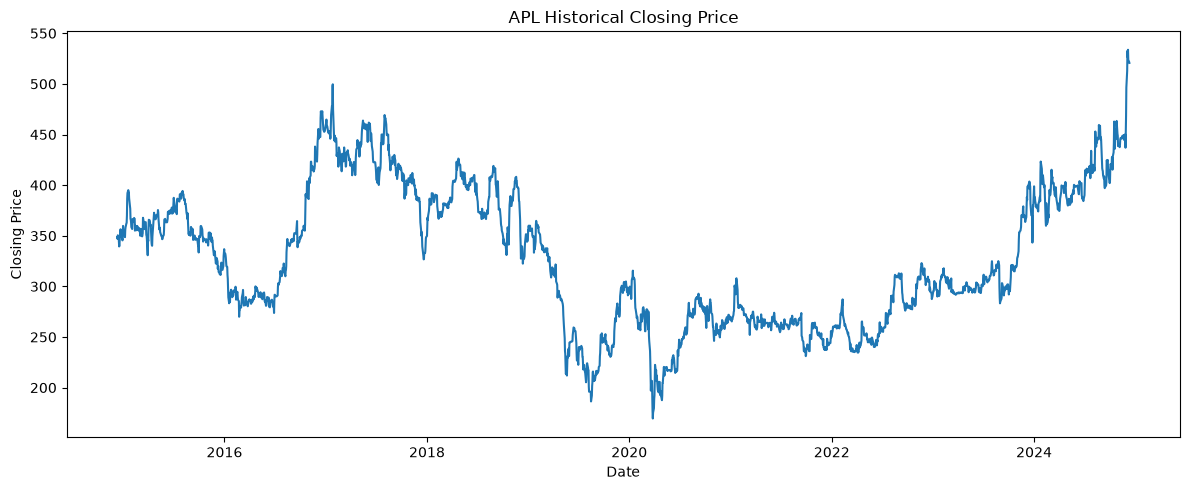

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(close_prices)

plt.title("APL Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.tight_layout()
plt.show()

## 6. Descriptive Statistics

Basic statistical measures are calculated to understand the distribution
and overall behavior of the closing prices.

In [24]:
close_prices.describe()

count    2598.000000
mean      327.390739
std        68.283240
min       169.496002
25%       269.928009
50%       314.266678
75%       384.951660
max       533.710022
Name: APL.KA, dtype: float64

## 7. Testing for Stationarity

ARIMA models require the time series to be stationary or to be transformed
into a stationary series.

The Augmented Dickey-Fuller (ADF) test is used to check whether the original
APL closing price series is stationary.

A p-value below 0.05 indicates that the series is stationary.

In [25]:
adf_test = adfuller(close_prices)

print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])

print("\nCritical Values:")
for key, value in adf_test[4].items():
    print(f"{key}: {value}")

ADF Statistic: -1.3090537082176095
p-value: 0.625020119090346

Critical Values:
1%: -3.432878310326342
5%: -2.8626570109517075
10%: -2.567364625328271


C:\Users\Hamza Ali\AppData\Local\Temp\ipykernel_21932\592923939.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_test = adfuller(close_prices)


## 8. First-Order Differencing

If the original closing price series is not stationary, first-order
differencing is applied.

The differenced series represents the change in closing price from one
trading day to the next.

For the ARIMA model, this corresponds to d = 1.

In [26]:
close_diff = close_prices.diff().dropna()

close_diff.head()

Date
2014-12-11   -1.739990
2014-12-12    3.446655
2014-12-15   -1.126648
2014-12-16   -5.953339
2014-12-17   -3.953339
Name: APL.KA, dtype: float64

## 9. Visualizing the Differenced Series

The differenced series is plotted to check whether the transformation
has reduced the trend and made the series more stable over time.

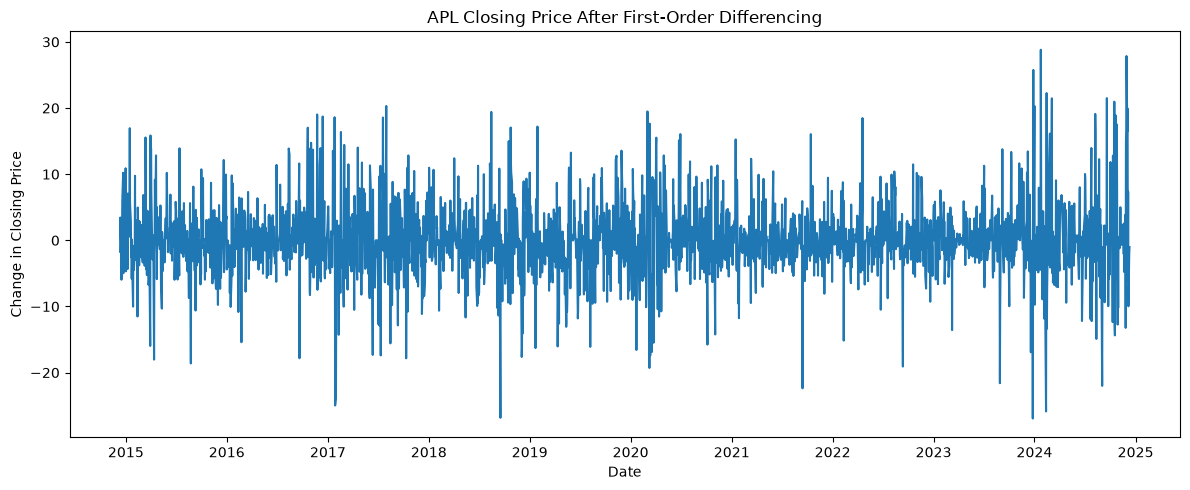

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(close_diff)

plt.title("APL Closing Price After First-Order Differencing")
plt.xlabel("Date")
plt.ylabel("Change in Closing Price")

plt.tight_layout()
plt.show()

## 10. ADF Test After Differencing

The ADF test is performed again after first-order differencing.

If the p-value is below 0.05, the differenced series can be considered
stationary and is suitable for ARIMA modeling.

In [28]:
adf_diff = adfuller(close_diff)

print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

print("\nCritical Values:")
for key, value in adf_diff[4].items():
    print(f"{key}: {value}")

ADF Statistic: -17.53118008573488
p-value: 4.236090400020747e-30

Critical Values:
1%: -3.432878310326342
5%: -2.8626570109517075
10%: -2.567364625328271


C:\Users\Hamza Ali\AppData\Local\Temp\ipykernel_21932\3008148189.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_diff = adfuller(close_diff)


## 11. Autocorrelation Analysis

The Autocorrelation Function (ACF) is used to examine the relationship
between the current values of the differenced series and its previous values.

The ACF plot can help in selecting an appropriate value for the moving
average (MA) component of the ARIMA model.

<Figure size 1200x500 with 0 Axes>

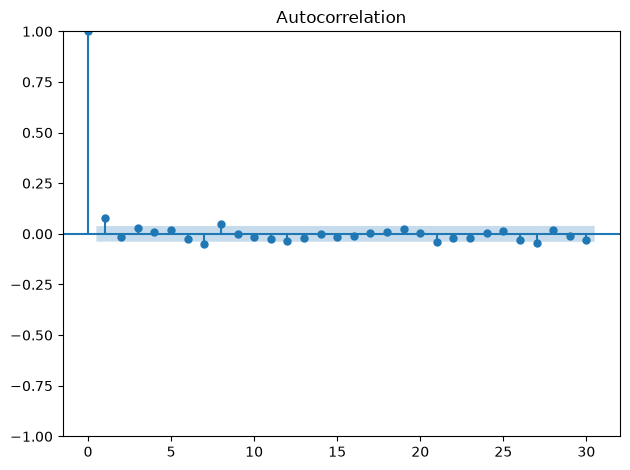

In [29]:
plt.figure(figsize=(12, 5))

plot_acf(close_diff, lags=30)

plt.tight_layout()
plt.show()

## 12. Partial Autocorrelation Analysis

The Partial Autocorrelation Function (PACF) shows the relationship between
the current value and its lagged values while controlling for the effects
of intermediate lags.

The PACF can help in selecting the autoregressive (AR) component of the model.

<Figure size 1200x500 with 0 Axes>

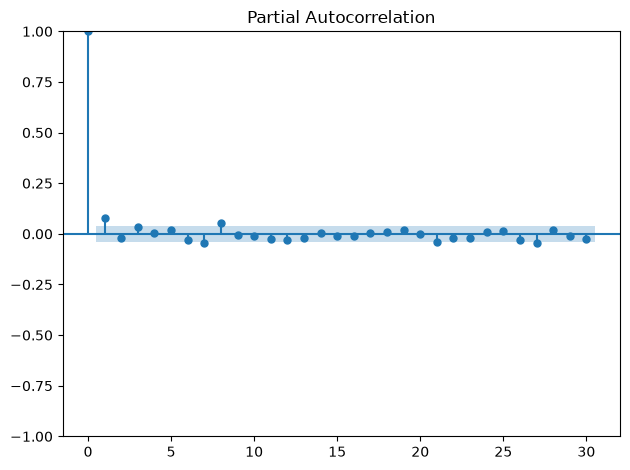

In [30]:
plt.figure(figsize=(12, 5))

plot_pacf(close_diff, lags=30, method="ywm")

plt.tight_layout()
plt.show()

## 13. Building the ARIMA Model

Based on the time-series analysis, an ARIMA(1,1,1) model is fitted to the
historical APL closing prices.

The model uses:

- p = 1: one autoregressive term
- d = 1: first-order differencing
- q = 1: one moving average term

In [31]:
# Prepare the closing price data
arima_data = close_prices.copy()

# Make sure the values are numeric
arima_data = pd.to_numeric(arima_data, errors="coerce").dropna()

# Fit the ARIMA(1,1,1) model
model = ARIMA(
    arima_data.values,
    order=(1, 1, 1)
)

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2598
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -8054.630
Date:                Tue, 08 Sep 2026   AIC                          16115.260
Time:                        17:00:53   BIC                          16132.846
Sample:                             0   HQIC                         16121.632
                               - 2598                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3880      0.144     -2.685      0.007      -0.671      -0.105
ma.L1          0.4651      0.140      3.319      0.001       0.190       0.740
sigma2        28.9373      0.488     59.320      0.0

In [32]:
print("Type:", type(arima_data))
print("Index type:", type(arima_data.index))
print("Index dtype:", arima_data.index.dtype)
print("First 5 dates:")
print(arima_data.index[:5])

print("\nLast 5 dates:")
print(arima_data.index[-5:])

print("\nModel data index:")
print(model_fit.model.data.row_labels)

Type: <class 'pandas.Series'>
Index type: <class 'pandas.DatetimeIndex'>
Index dtype: datetime64[s]
First 5 dates:
DatetimeIndex(['2014-12-10', '2014-12-11', '2014-12-12', '2014-12-15',
               '2014-12-16'],
              dtype='datetime64[s]', name='Date', freq=None)

Last 5 dates:
DatetimeIndex(['2024-12-04', '2024-12-05', '2024-12-06', '2024-12-09',
               '2024-12-10'],
              dtype='datetime64[s]', name='Date', freq=None)

Model data index:
None


## 14. Forecasting Future Closing Prices

The fitted ARIMA model is used to forecast the next five trading periods.

This provides a short-term estimate of where the APL closing price may move
based on patterns identified in the historical data.

In [33]:
# Number of future periods
forecast_steps = 5

# Generate the forecast
forecast_values = model_fit.forecast(
    steps=forecast_steps
)

print("Forecast for the next 5 trading periods:")
print(forecast_values)

Forecast for the next 5 trading periods:
[520.45547719 520.56585802 520.52303423 520.53964832 520.53320265]


## 15. Creating Forecast Dates

Since stock markets do not operate on weekends, business days are used
for the forecast dates rather than consecutive calendar days.

In [34]:
# Get the last date in the dataset
last_date = close_prices.index[-1]

# Create the next five business dates
forecast_dates = pd.bdate_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_steps
)

# Create a table containing the forecast
forecast_df = pd.DataFrame({
    "Date": forecast_dates,
    "Forecast Price": np.asarray(forecast_values)
})

forecast_df

,Date,Forecast Price
0,2024-12-11,520.455477
1,2024-12-12,520.565858
2,2024-12-13,520.523034
3,2024-12-16,520.539648
4,2024-12-17,520.533203


## 16. Visualizing the Forecast

The historical APL closing prices are plotted together with the forecasted
prices to show the expected short-term movement.

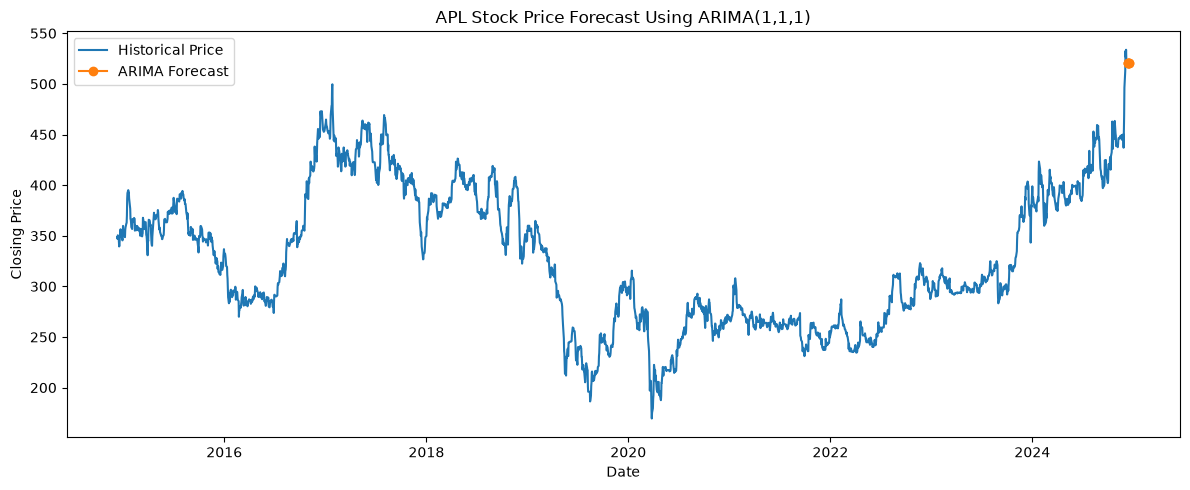

In [35]:
plt.figure(figsize=(12, 5))

plt.plot(
    close_prices.index,
    close_prices.values,
    label="Historical Price"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast Price"],
    marker="o",
    label="ARIMA Forecast"
)

plt.title("APL Stock Price Forecast Using ARIMA(1,1,1)")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()
plt.tight_layout()
plt.show()

## 17. Forecast Results

The table below shows the predicted closing prices for the next
five trading periods.

In [36]:
forecast_df

,Date,Forecast Price
0,2024-12-11,520.455477
1,2024-12-12,520.565858
2,2024-12-13,520.523034
3,2024-12-16,520.539648
4,2024-12-17,520.533203


## 18. Conclusion

This project analyzed the historical stock prices of Attock Petroleum
Limited using exploratory and time-series analysis techniques.

The Augmented Dickey-Fuller test was used to check for stationarity,
followed by first-order differencing. ACF and PACF plots were then
used to examine the autocorrelation structure of the series.

An ARIMA(1,1,1) model was fitted to the historical closing prices and
used to generate a five-period forecast. The results provide a
short-term estimate based on historical price patterns. However,
stock prices are affected by many external factors, so the forecast
should not be considered a guaranteed prediction of future prices.